In [38]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D, SimpleRNN, Input
from tensorflow.keras.optimizers import Adam

# Fijamos semillas de aleatoriedad fija
np.random.seed(42)
tf.random.set_seed(42)

In [39]:
# Crear un mini dataset de frases

# Lista de frases de ejemplo
frases = [
    "me gusta esta pelicula", "no me gusta esta pelicula",
    "esta pelicula es buena", "esta pelicula no es buena",
    "me encanta este restaurante", "no me encanta este restaurante",
    "este restaurante es bueno", "este restaurante no es bueno",
    "el servicio fue excelente", "el servicio no fue excelente",
    "la comida estuvo deliciosa", "la comida no estuvo deliciosa",
    "amo esta cancion", "no amo esta cancion", "este libro es interesante",
    "este libro no es interesante", "el curso fue util",
    "el curso no fue util", "me parece fantastico",
    "no me parece fantastico", "la experiencia fue agradable",
    "la experiencia no fue agradable", "me gusta mucho este lugar",
    "no me gusta mucho este lugar", "el producto funciona bien",
    "el producto no funciona bien", "la app es rapida",
    "la app no es rapida", "el hotel fue comodo",
    "el hotel no fue comodo", "la pelicula fue aburrida",
    "la pelicula no fue aburrida", "el restaurante fue terrible",
    "el restaurante no fue terrible", "la clase estuvo confusa",
    "la clase no estuvo confusa", "el libro fue pesado",
    "el libro no fue pesado", "el sistema es malo",
    "el sistema no es malo"
]
# Etiquetas: 1 para sentimineto positivo, 0 para negativo.
# se mapean 1 a 1 con la lista de frases de arriba
etiquetas = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1
]

# Convertimos las dos listas en un DataFrame para vizualizarlo mejor en forma de tabla
df = pd.DataFrame({
    'frase': frases,
    'etiqueta': etiquetas
})

print(df.head(10))
print("\nTotal de ejemplos:", len(df))

                            frase  etiqueta
0          me gusta esta pelicula         1
1       no me gusta esta pelicula         0
2          esta pelicula es buena         1
3       esta pelicula no es buena         0
4     me encanta este restaurante         1
5  no me encanta este restaurante         0
6       este restaurante es bueno         1
7    este restaurante no es bueno         0
8       el servicio fue excelente         1
9    el servicio no fue excelente         0

Total de ejemplos: 40


In [40]:
#  Verificar el balance de clases
print(df['etiqueta'].value_counts())

etiqueta
1    20
0    20
Name: count, dtype: int64


In [41]:
# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(
    frases,
    etiquetas,
    test_size=.25,
    stratify=etiquetas
)

print("Numero de frases de entrenamiento:", len(X_train))
print("Numero de frases de prueba:", len(X_test))

Numero de frases de entrenamiento: 30
Numero de frases de prueba: 10


In [42]:
# Tokenizar el texto
tokenizer = Tokenizer(oov_token="<OOV>")
# OOV (Out of Vocabulary): Si en el futuro la red lee una palabra que nunca vio
#al entrenar, en lugar de ingnorarla le pondra la etiqueta OOV.

tokenizer.fit_on_texts(X_train)
# fit_on_texts lee todas las frases de entrenamiento y crea el diccionario de palabras.

word_index= tokenizer.word_index
# word_index es un diccionario de python que guarda la relacion "palabra: numero"

print("Tamaño del vocabulario:", len(word_index))
print("\nPrimeras palabras del vocabulario:")
for i, (palabra, indice) in enumerate(word_index.items()):
  if i >= 15:
    break
  print(f"{palabra}: {indice}")

Tamaño del vocabulario: 46

Primeras palabras del vocabulario:
<OOV>: 1
no: 2
el: 3
fue: 4
es: 5
la: 6
me: 7
este: 8
restaurante: 9
pelicula: 10
libro: 11
estuvo: 12
esta: 13
encanta: 14
sistema: 15


In [43]:
# Conversion de frases a secuencias numericas

# texts_to_sequences sustituye cada palabra por su numero de diccionario
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Ejemplo de frase original:", X_train[0])
print("Ejemplo de frase convertida:", X_train_seq[0])

#Buscamos la longitud de la oracion con mas palabras
max_len= max(len(seq) for seq in X_train_seq)
print("\nLongitud maxima encontrada:", max_len)

# Pad_sequences rellena con ceros las oraciones cortas
# padding= "post" significa que pone los ceros al final (a la derecha)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

print("\nForma de X_train_pad:", X_train_pad.shape)
print(" Ejemplo con padding:")
print(X_train_pad[0])

Ejemplo de frase original: me encanta este restaurante
Ejemplo de frase convertida: [7, 14, 8, 9]

Longitud maxima encontrada: 6

Forma de X_train_pad: (30, 6)
 Ejemplo con padding:
[ 7 14  8  9  0  0]


In [55]:
# Modelo base (Red tradicional sin Memoria)

# Le sumamos 1 al vocabulario por que Keras usa el numero 0 para el padding
vocab_size = len(word_index) + 1

# Decidimos que cada palabra se representara con un vector de 16 dimensiones
embedding_dim = 16

# Creamos un modelo secuencial (capa tras capa)
modelo_base = Sequential([
    # Declaramos explicitamente la forma de la entrada antes del embedding
    Input(shape=(max_len,)),
    # Capa 1: Embedding. Recibe los numeros enteros y devuleve vectores densos de 16 dimensiones
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    # Capa 2: Promedio. Aplasta toda la oracion sumando y promediando las palabras.
    # Cuidado! Al hacer esto, perdemos el orden de la secuencia.
    GlobalAveragePooling1D(),
    # Capa 3: Capa oculta con 16 neuronas y activacion ReLU (para aprender patrones no lineales)
    Dense(16, activation="relu"),
    # Capa 4: Salida de 1 sola neurona el Sigmoid obliga a dar resultados entre 0 y 1
    Dense(1, activation="sigmoid")
])

modelo_base.compile(
    optimizer=Adam(learning_rate=0.001), # Adam ajusta los pesos de la red
    loss="binary_crossentropy", #Funcion de error es ideal para problemas binarios
    metrics=["accuracy"] #Queremos que nos reporte el porcentaje de aciertos.
)

modelo_base.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 6, 16)          │           752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Entrenamos el modelo base

hist_base = modelo_base.fit(
    X_train_pad, # Datos de entrenamiento
    np.array(y_train), # Respuestas correctas
    epochs=40, # El modelo vera todos los datos 40 veces
    validation_split = 0.25, # Separa 20% del train para validarse en cada epoca sin hacer trampa
    verbose=1 #verbose=0 oculta el texto de entrenamiento en cada epoca para no saturar la pantalla
)

print("Entrenamiento del modelo base completado")

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3636 - loss: 0.6947 - val_accuracy: 0.3750 - val_loss: 0.6925
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5455 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5455 - loss: 0.6933 - val_accuracy: 0.6250 - val_loss: 0.6926
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5455 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6364 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6818 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7273 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7273 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.

In [57]:
# Modelo con RNN (Red con Memoria)

modelo_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(16, activation="tanh"),
    Dense(1, activation="sigmoid")
])

modelo_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_rnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 6, 16)          │           752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Entrenamos la RNN

hist_rnn = modelo_rnn.fit(
    X_train_pad,
    np.array(y_train),
    epochs=40,
    validation_split=0.25,
    verbose=1
)
print("Entrenamiento del modelo RNN completado")

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4091 - loss: 0.7012 - val_accuracy: 0.7500 - val_loss: 0.6851
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 0.6962 - val_accuracy: 0.7500 - val_loss: 0.6861
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6364 - loss: 0.6912 - val_accuracy: 0.7500 - val_loss: 0.6872
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6364 - loss: 0.6863 - val_accuracy: 0.7500 - val_loss: 0.6882
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6364 - loss: 0.6814 - val_accuracy: 0.6250 - val_loss: 0.6892
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6818 - loss: 0.6765 - val_accuracy: 0.6250 - val_loss: 0.6902
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7273 - loss: 0.6715 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7727 - loss: 0.6664 - val_accuracy: 0.5000 - val_loss: 0.6923
E

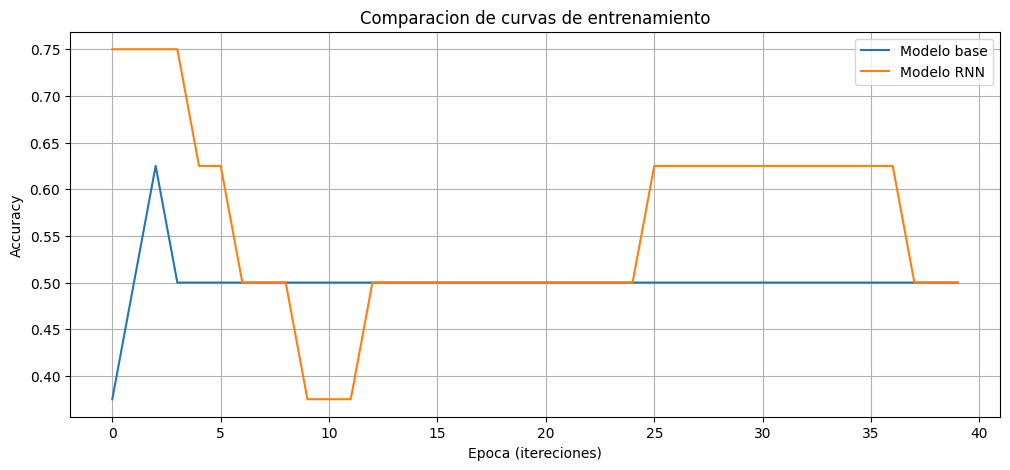

In [59]:
# Comparamos curvas de entrenamiento
plt.figure(figsize=(12, 5))

plt.plot(hist_base.history["val_accuracy"], label="Modelo base")
plt.plot(hist_rnn.history["val_accuracy"], label="Modelo RNN")
plt.title("Comparacion de curvas de entrenamiento")
plt.xlabel("Epoca (itereciones)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# Evaluar en el conjunto y su desempeño en frases no vistas

loss_base, acc_base = modelo_base.evaluate(X_test_pad, np.array(y_test), verbose=0)
loss_rnn, acc_rnn = modelo_rnn.evaluate(X_test_pad, np.array(y_test), verbose=0)

print(f"Resultado en Prueba Modelo base: Accuracy del {acc_base*100:.2f}%")
print(f"Resultado en Prueba Modelo RNN: Accuracy del {acc_rnn*100:.2f}%")

Resultado en Prueba Modelo base: Accuracy del 20.00%
Resultado en Prueba Modelo RNN: Accuracy del 70.00%


In [61]:
# Probar con frases nuevas en tiempo real

frases_nuevas=[
    "me gusta este libro",
    "no me gusta este libro",
    "esta pelicula es buena",
    "esta pelicula es mala",
    "el sistema es malo",
    "el sistema no es malo",
    "la app es rapida",
    "la app no es rapida"
]

seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

# .predict nos devuelve un array con probabilidades (ej: 0.85 = muy positivo, 0.12 = muy negativo)
pred_base = modelo_base.predict(pad_nuevas, verbose=0)
pred_rnn = modelo_rnn.predict(pad_nuevas, verbose=0)

print("Prediciones sobre frases nuevas (Cercano a 1 = Positivo, Cercano a 0 = Negativo):\n")
for i, frase in enumerate(frases_nuevas):
  print(f"Frase: '{frase}'")
  print(f" Modelo base (Ignora el orden): {pred_base[i][0]:.4f}")
  print(f" Modelo RNN (Lee en orden): {pred_rnn[i][0]:.4f}")
  print("_"*60)


Prediciones sobre frases nuevas (Cercano a 1 = Positivo, Cercano a 0 = Negativo):

Frase: 'me gusta este libro'
 Modelo base (Ignora el orden): 0.5140
 Modelo RNN (Lee en orden): 0.7516
____________________________________________________________
Frase: 'no me gusta este libro'
 Modelo base (Ignora el orden): 0.4874
 Modelo RNN (Lee en orden): 0.1726
____________________________________________________________
Frase: 'esta pelicula es buena'
 Modelo base (Ignora el orden): 0.4977
 Modelo RNN (Lee en orden): 0.6303
____________________________________________________________
Frase: 'esta pelicula es mala'
 Modelo base (Ignora el orden): 0.4939
 Modelo RNN (Lee en orden): 0.6131
____________________________________________________________
Frase: 'el sistema es malo'
 Modelo base (Ignora el orden): 0.5167
 Modelo RNN (Lee en orden): 0.7936
____________________________________________________________
Frase: 'el sistema no es malo'
 Modelo base (Ignora el orden): 0.5021
 Modelo RNN (Lee en 